# Check DE: Test AUC Across FDR Settings

This notebook compares **test AUC** across saved `check_de.py` runs with different DE FDR thresholds.


In [5]:
import os
import re

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch_geometric

from SDAN.preprocess import qc, construct_GNN, construct_labels
from SDAN.train import test_model

SEED = 888
np.random.seed(SEED)
torch.manual_seed(SEED)

sc.settings.verbosity = 1


In [6]:
# Parameters
data_dir = './Zheng_2017/'
cell_types = ['cd4_t_helper', 'naive_t']

# Optional: set manually if you only want specific FDR values
requested_fdrs = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

In [7]:
def load_biogrid_edges():
    candidates = [
        './Annotation/BIOGRID-ORGANISM-Homo_sapiens-4.4.204.tab3.txt.gz',
        './Annotation/BIOGRID-ORGANISM-Homo_sapiens-4.4.204.tab3.txt',
    ]
    biogrid_path = next((p for p in candidates if os.path.exists(p)), None)
    if biogrid_path is None:
        raise FileNotFoundError('Could not find BIOGRID file in ./Annotation/ (.txt.gz or .txt).')

    return pd.read_csv(
        biogrid_path,
        sep='\t',
        low_memory=False,
        usecols=['Official Symbol Interactor A', 'Official Symbol Interactor B'],
        dtype='string',
    )


def construct_gene_graph_cached(gene_list, biogrid_edges):
    mapping = pd.Series(range(len(gene_list)), index=gene_list)
    edge_df = biogrid_edges[
        (biogrid_edges['Official Symbol Interactor A'].isin(gene_list)) &
        (biogrid_edges['Official Symbol Interactor B'].isin(gene_list))
    ]

    edge_index = torch.as_tensor(
        np.vstack([
            edge_df.iloc[:, 0].map(mapping).to_numpy(dtype=np.int64),
            edge_df.iloc[:, 1].map(mapping).to_numpy(dtype=np.int64),
        ]),
        dtype=torch.long,
    )
    edge_index = torch.unique(edge_index, dim=1)
    edge_index = torch_geometric.utils.to_undirected(edge_index)
    edge_index, _ = torch_geometric.utils.remove_self_loops(edge_index)
    return edge_index


def parse_fdr_from_label(label):
    # label format: de_fdr_0p05 -> 0.05
    if not label.startswith('de_fdr_'):
        return np.nan
    return float(label.replace('de_fdr_', '').replace('p', '.'))


def discover_de_runs(output_dir, cell_type_str):
    pattern = re.compile(rf'^model_{re.escape(cell_type_str)}_(de_fdr_[0-9]+(?:p[0-9]+)?)\.pth$')
    rows = []

    for fn in os.listdir(output_dir):
        m = pattern.match(fn)
        if m is None:
            continue

        label = m.group(1)
        run_prefix = f'{cell_type_str}_{label}'
        gene_list_path = os.path.join(output_dir, f'gene_list_{run_prefix}.txt')
        train_s_path = os.path.join(output_dir, f'train_s_{run_prefix}.npy')
        model_path = os.path.join(output_dir, f'model_{run_prefix}.pth')

        if not (os.path.exists(gene_list_path) and os.path.exists(train_s_path) and os.path.exists(model_path)):
            continue

        rows.append({
            'label': label,
            'fdr': parse_fdr_from_label(label),
            'gene_list_path': gene_list_path,
            'train_s_path': train_s_path,
            'model_path': model_path,
        })

    run_df = pd.DataFrame(rows)
    if run_df.empty:
        return run_df

    run_df = run_df.sort_values('fdr').reset_index(drop=True)
    return run_df


Detected DE runs:
      label  fdr
de_fdr_0p05 0.05
 de_fdr_0p1 0.10
 de_fdr_0p2 0.20
 de_fdr_0p3 0.30
 de_fdr_0p4 0.40
 de_fdr_0p5 0.50
The proportion of non-isolated genes: 0.91
The proportion of non-isolated genes: 0.91
The proportion of non-isolated genes: 0.92
The proportion of non-isolated genes: 0.92
The proportion of non-isolated genes: 0.91
The proportion of non-isolated genes: 0.90


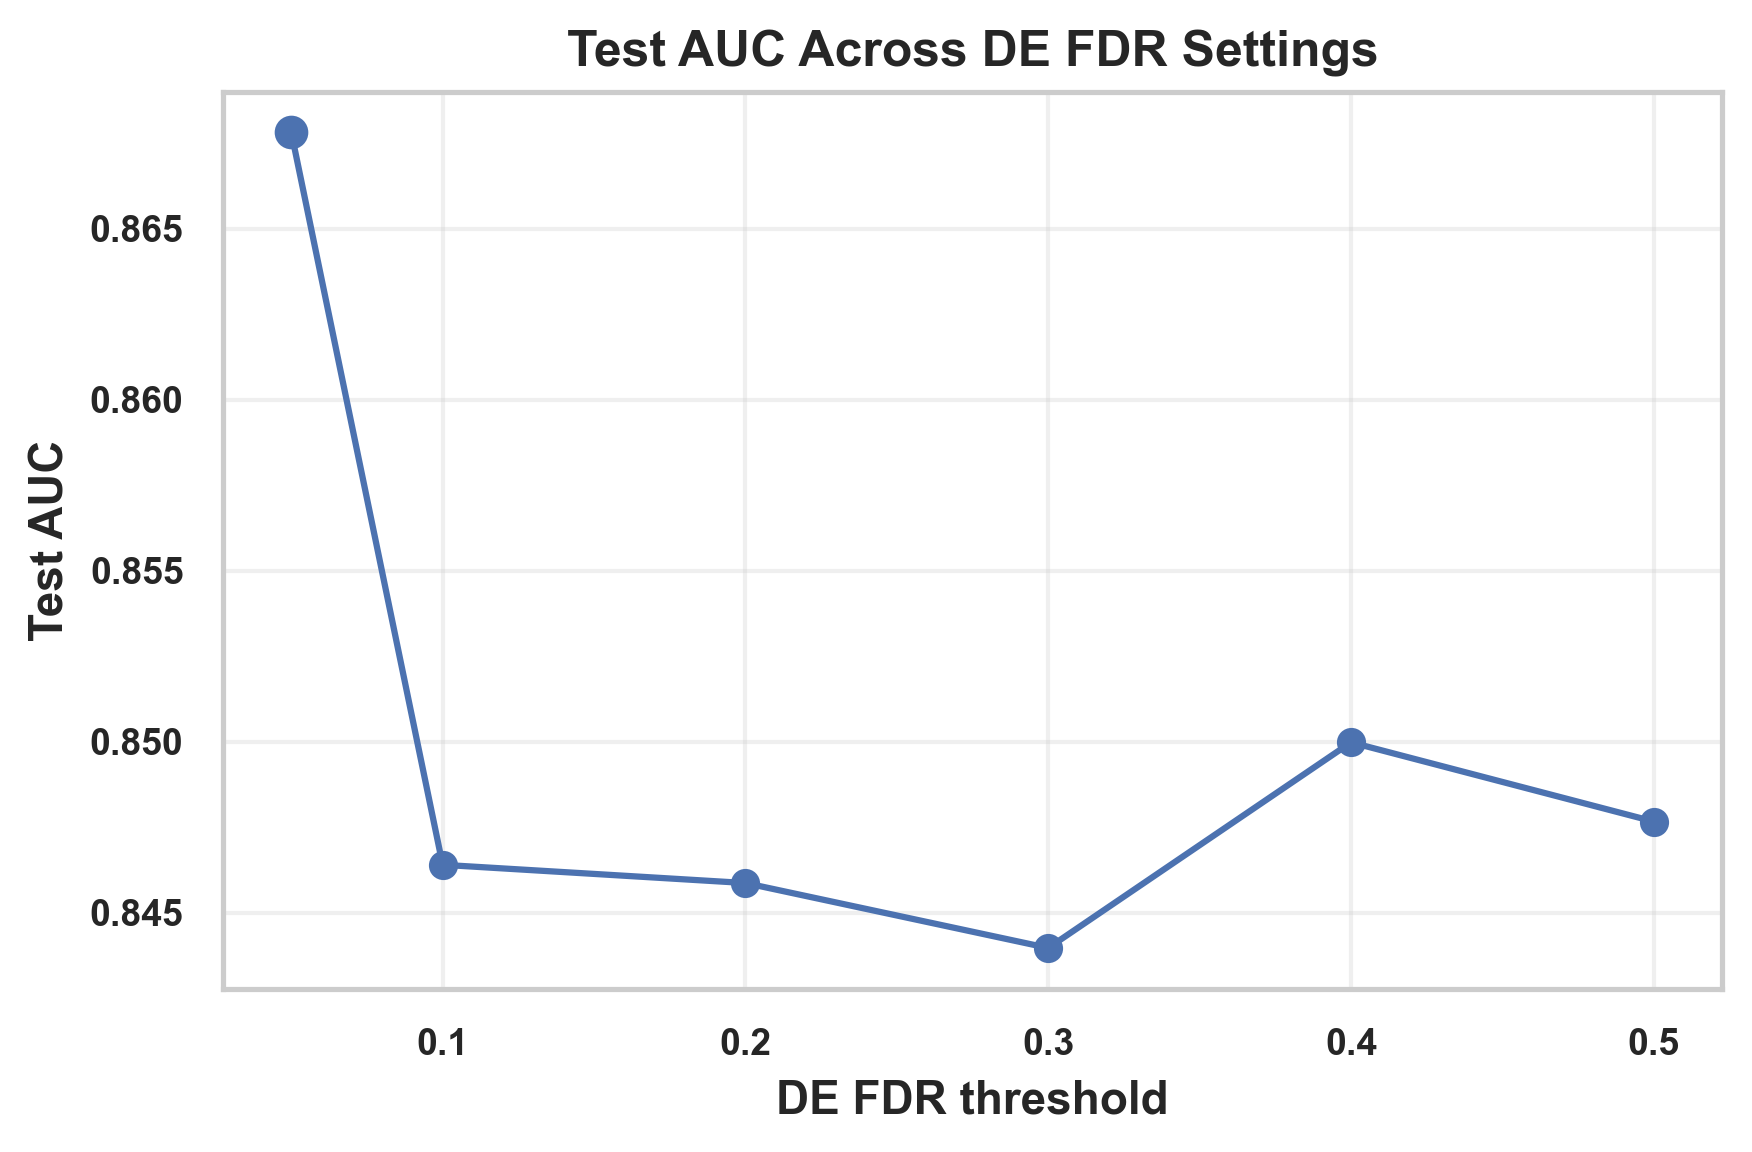

Saved figure: ./Zheng_2017/figures/check_de/cd4_t_helper-naive_t_de_fdr_test_auc_from_saved_models.pdf
Saved summary: ./Zheng_2017/output/check_de/comparison_de_fdr_cd4_t_helper-naive_t.csv


,fdr,label,n_genes,test_auc,test_loss
0,0.05,de_fdr_0p05,1858,0.867824,0.468981
4,0.40,de_fdr_0p4,3793,0.849980,0.481292
5,0.50,de_fdr_0p5,4369,0.847663,0.486874
1,0.10,de_fdr_0p1,2243,0.846398,0.483908
2,0.20,de_fdr_0p2,2855,0.845865,0.503893
3,0.30,de_fdr_0p3,3411,0.843966,0.496169


In [8]:
d = data_dir
output_dir = os.path.join(d, 'output/check_de')
check_dir = os.path.join(d, 'figures', 'check_de')
os.makedirs(check_dir, exist_ok=True)

cell_type_str = '-'.join(cell_types)
run_df = discover_de_runs(output_dir, cell_type_str)

if run_df.empty:
    raise FileNotFoundError(
        f'No saved DE runs found in {output_dir} for {cell_type_str}. '
        f'Run check_de.py with different --fdr values first.'
    )

if requested_fdrs is not None:
    requested_fdrs = sorted([float(x) for x in requested_fdrs])
    run_df = run_df[run_df['fdr'].isin(requested_fdrs)].reset_index(drop=True)

if run_df.empty:
    raise ValueError('No runs left after filtering requested_fdrs.')

print('Detected DE runs:')
print(run_df[['label', 'fdr']].to_string(index=False))

# Load test data once
test_data = sc.read(f'{d}sc9_test.h5ad')
qc(test_data)
test_data = test_data[test_data.obs.cell_type.isin(cell_types), :]
test_labels = construct_labels(test_data, cell_types)

biogrid_edges = load_biogrid_edges()

records = []
for _, run in run_df.iterrows():
    gene_list = pd.Index(pd.read_csv(run['gene_list_path'], header=None).squeeze())
    edge_index = construct_gene_graph_cached(gene_list, biogrid_edges)
    test_GNN = construct_GNN(test_data, gene_list, edge_index)

    model = torch.load(run['model_path'], map_location='cpu', weights_only=False)
    model.eval()

    train_s = torch.as_tensor(np.load(run['train_s_path']), dtype=test_GNN.x.dtype)
    test_reduced = test_GNN.x.t() @ train_s

    _, test_loss, test_auc = test_model(model, test_reduced, test_labels)

    records.append({
        'fdr': float(run['fdr']),
        'label': run['label'],
        'n_genes': int(len(gene_list)),
        'test_auc': float(test_auc),
        'test_loss': float(test_loss.item()),
    })

result_df = pd.DataFrame(records).sort_values('fdr').reset_index(drop=True)

sns.set_theme(style='whitegrid')
plt.figure(figsize=(6, 4), dpi=300)
plt.plot(result_df['fdr'], result_df['test_auc'], marker='o')
best_idx = result_df['test_auc'].idxmax()
plt.scatter(result_df.loc[best_idx, 'fdr'], result_df.loc[best_idx, 'test_auc'], s=50)
plt.xlabel('DE FDR threshold', fontsize=11, fontweight='bold')
plt.ylabel('Test AUC', fontsize=11, fontweight='bold')
plt.title('Test AUC Across DE FDR Settings', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig_path = os.path.join(check_dir, f'{cell_type_str}_de_fdr_test_auc_from_saved_models.pdf')
plt.savefig(fig_path)
plt.show()

csv_path = os.path.join(output_dir, f'comparison_de_fdr_{cell_type_str}.csv')
result_df.to_csv(csv_path, index=False)

print(f'Saved figure: {fig_path}')
print(f'Saved summary: {csv_path}')
result_df.sort_values('test_auc', ascending=False)


/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


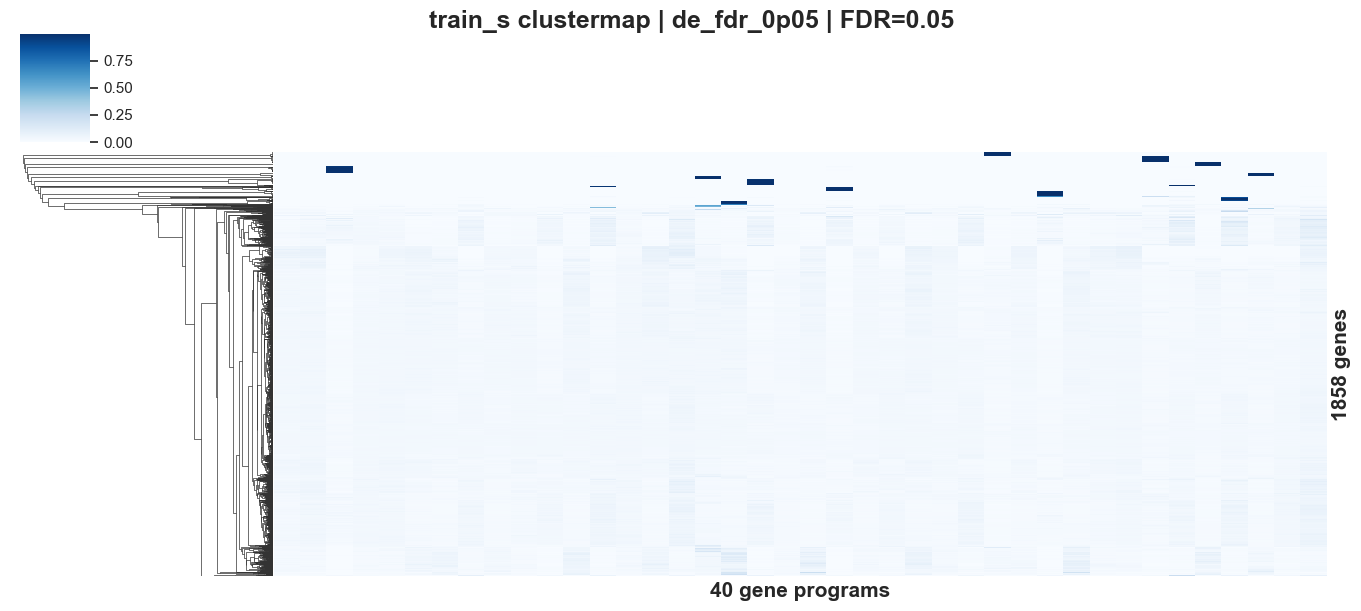

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


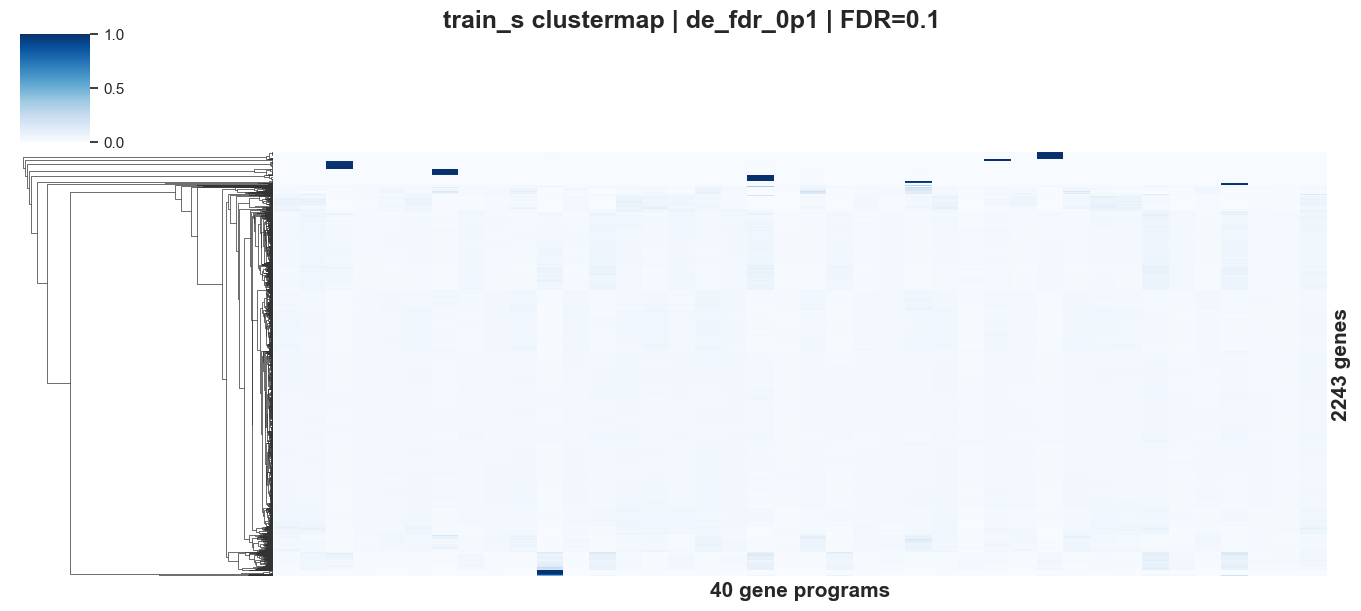

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


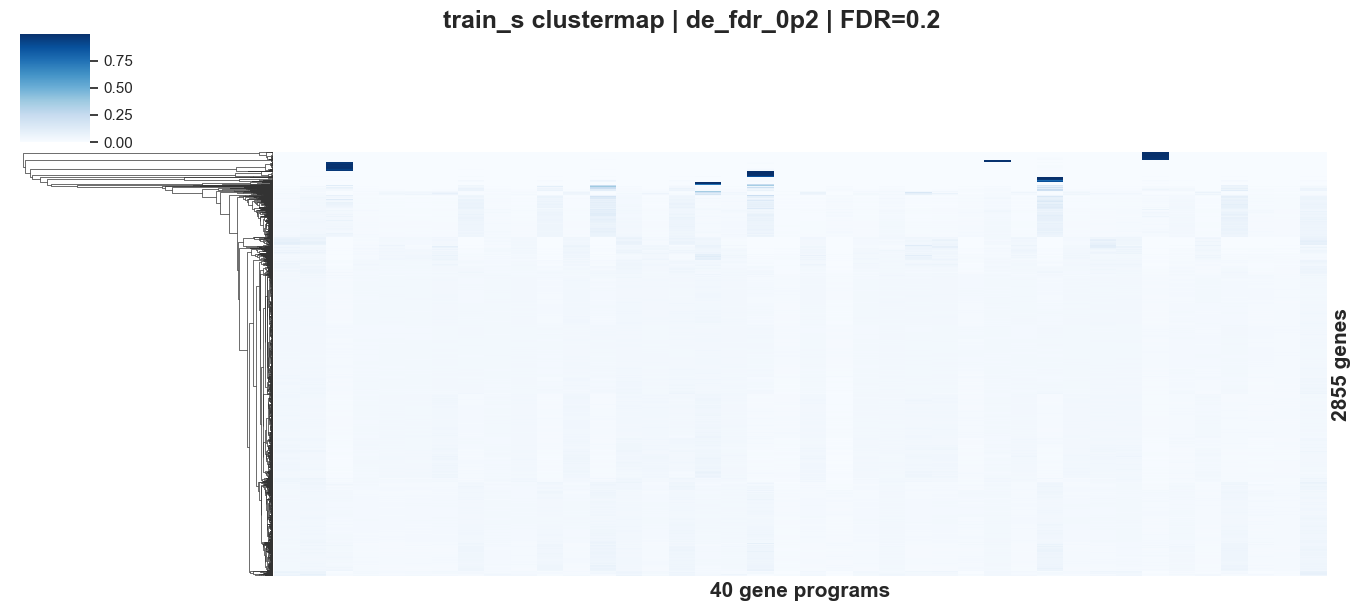

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


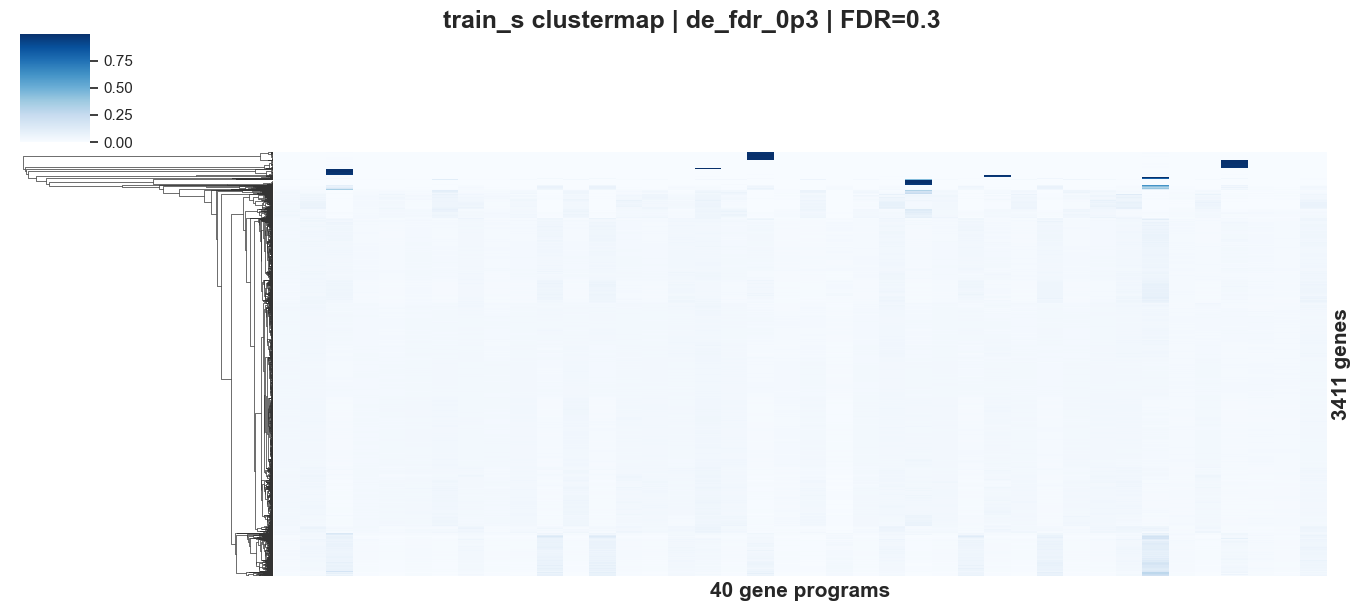

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


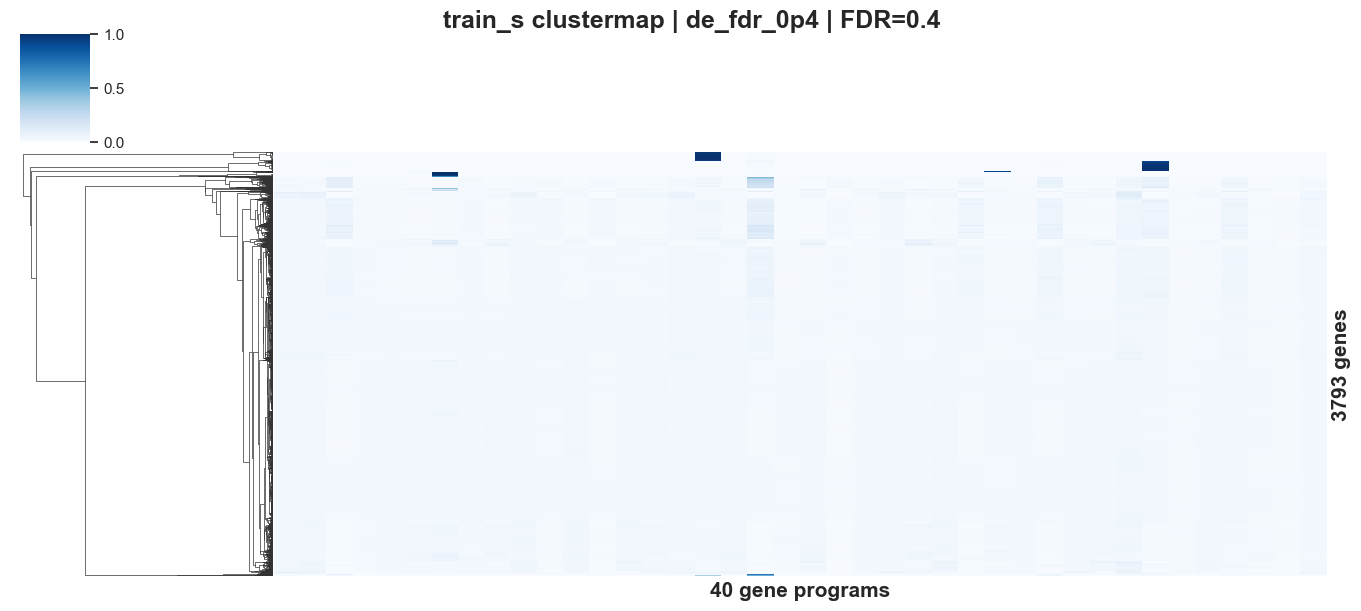

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


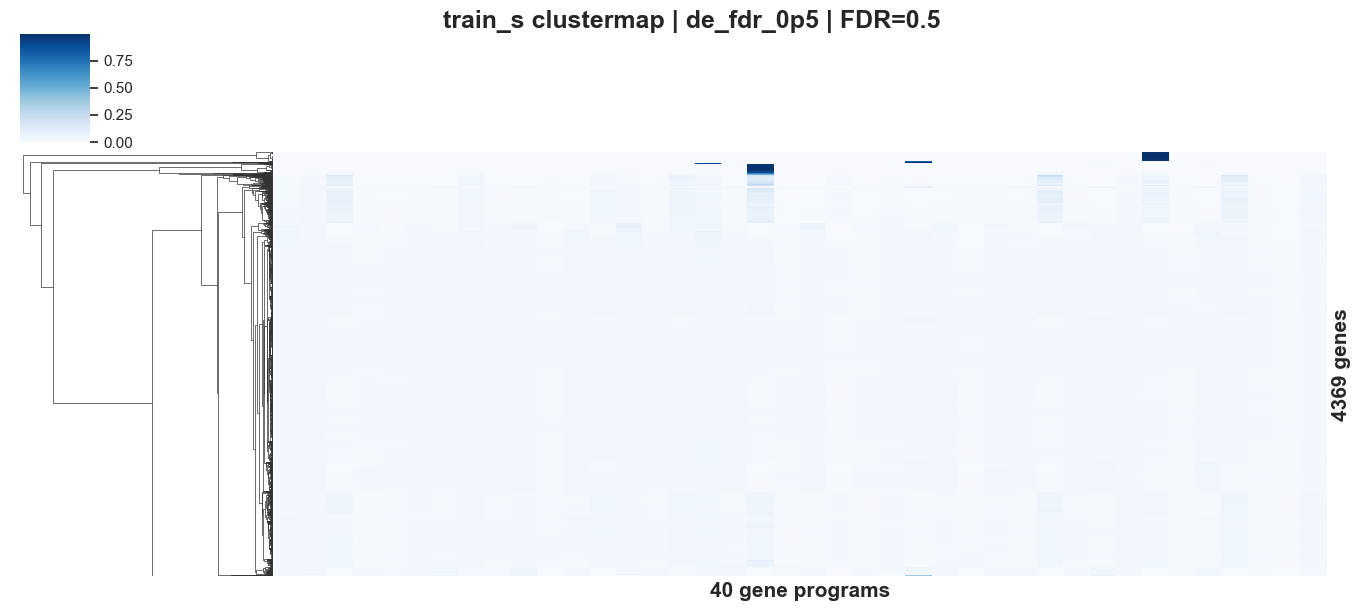

In [9]:
# Visualize all train_s matrices across FDR settings (display only, no save)
import seaborn as sns

for _, run in run_df.sort_values('fdr').iterrows():
    fdr = float(run['fdr'])
    label = run['label']
    train_s = np.load(run['train_s_path'])

    cg = sns.clustermap(train_s, col_cluster=False, cmap='Blues', figsize=(14, 6))
    cg.fig.suptitle(f'train_s clustermap | {label} | FDR={fdr:g}', y=1.02, fontsize=18, fontweight='bold')
    cg.ax_heatmap.set_xlabel('40 gene programs', fontsize=15, fontweight='bold')
    cg.ax_heatmap.set_ylabel(f'{train_s.shape[0]} genes', fontsize=15, fontweight='bold')
    cg.ax_heatmap.set_xticks([])
    cg.ax_heatmap.set_yticks([])
    plt.show()
    plt.close(cg.fig)


The proportion of non-isolated genes: 0.91
The proportion of non-isolated genes: 0.91
The proportion of non-isolated genes: 0.91
The proportion of non-isolated genes: 0.91
The proportion of non-isolated genes: 0.91
The proportion of non-isolated genes: 0.91
The proportion of non-isolated genes: 0.92
The proportion of non-isolated genes: 0.92
The proportion of non-isolated genes: 0.92
The proportion of non-isolated genes: 0.92
The proportion of non-isolated genes: 0.92
The proportion of non-isolated genes: 0.92
The proportion of non-isolated genes: 0.91
The proportion of non-isolated genes: 0.91
The proportion of non-isolated genes: 0.91
The proportion of non-isolated genes: 0.90
The proportion of non-isolated genes: 0.90
The proportion of non-isolated genes: 0.90


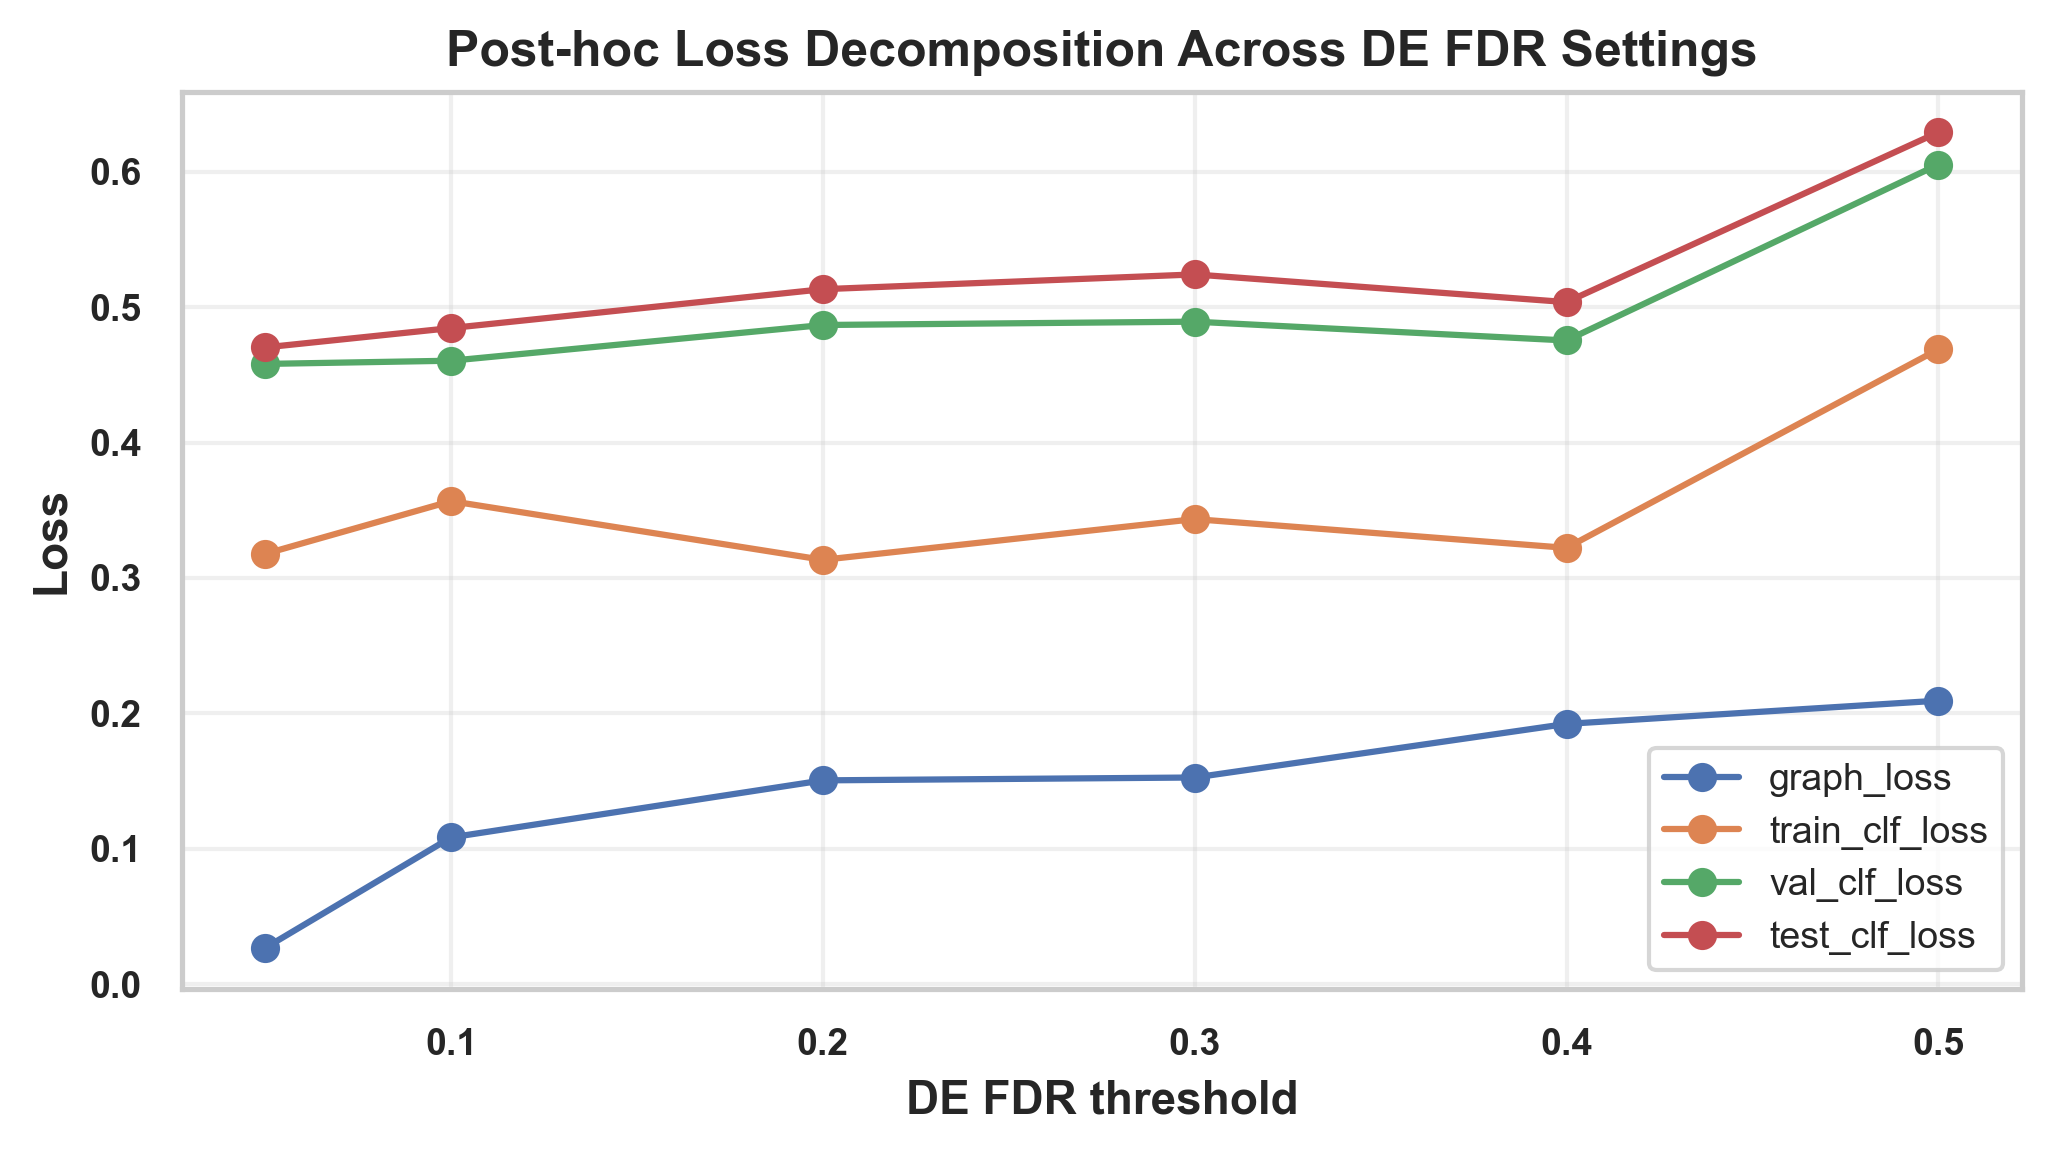

Saved figure: ./Zheng_2017/figures/check_de/cd4_t_helper-naive_t_de_fdr_loss_decomposition_posthoc.pdf
Saved summary: ./Zheng_2017/output/check_de/comparison_de_fdr_posthoc_loss_decomposition_cd4_t_helper-naive_t.csv


,fdr,label,graph_weight,graph_loss,train_clf_loss,val_clf_loss,test_clf_loss
0,0.05,de_fdr_0p05,1.0,0.026787,0.317811,0.458072,0.470266
1,0.10,de_fdr_0p1,1.0,0.108424,0.356740,0.460445,0.484571
2,0.20,de_fdr_0p2,1.0,0.150555,0.313402,0.486819,0.513249
3,0.30,de_fdr_0p3,1.0,0.152666,0.343484,0.489281,0.524171
4,0.40,de_fdr_0p4,1.0,0.192247,0.322239,0.475382,0.503714
5,0.50,de_fdr_0p5,1.0,0.209405,0.468857,0.605330,0.629128


In [10]:
# Post-hoc graph loss + clf loss across DE FDR settings (similar to check_graph.ipynb)
from SDAN.layers import PoolSuper


def infer_poolsuper_dims(state_dict):
    in_channels = state_dict['conv1.lin_rel.weight'].shape[1]
    hidden1 = state_dict['conv1.lin_rel.weight'].shape[0]
    hidden2 = state_dict['conv2.lin_rel.weight'].shape[0]
    n_comp = state_dict['pool.weight'].shape[0]
    out_channels = state_dict['linear_relu_stack.9.weight'].shape[0]
    return in_channels, hidden1, hidden2, n_comp, out_channels


def compute_posthoc_losses_like_trainpy(state_path, train_GNN, val_GNN, test_GNN, train_labels, val_labels, test_labels, graph_weight):
    # Mirror SDAN/train.py semantics: graph loss from train forward; clf losses from train/val/test logits.
    state_dict = torch.load(state_path, map_location='cpu')
    in_channels, hidden1, hidden2, n_comp, out_channels = infer_poolsuper_dims(state_dict)
    model = PoolSuper(in_channels, hidden1, hidden2, n_comp, out_channels)
    model.load_state_dict(state_dict)
    model.eval()

    criterion = torch.nn.CrossEntropyLoss()
    with torch.no_grad():
        train_logits, train_s, mc_loss, o_loss = model(train_GNN)
        graph_loss = graph_weight * mc_loss + graph_weight * o_loss
        train_clf_loss = criterion(train_logits, train_labels)

        val_reduced = val_GNN.x.t() @ train_s
        val_logits = model.linear_relu_stack(val_reduced)
        val_clf_loss = criterion(val_logits, val_labels)

        test_reduced = test_GNN.x.t() @ train_s
        test_logits = model.linear_relu_stack(test_reduced)
        test_clf_loss = criterion(test_logits, test_labels)

    return (
        float(graph_loss.item()),
        float(train_clf_loss.item()),
        float(val_clf_loss.item()),
        float(test_clf_loss.item()),
    )


d = data_dir
output_dir = os.path.join(d, 'output/check_de')
check_dir = os.path.join(d, 'figures', 'check_de')
os.makedirs(check_dir, exist_ok=True)

# Recreate train/val/test split exactly as check_de.py
train_data_all = sc.read(f'{d}sc9_train.h5ad')
test_data = sc.read(f'{d}sc9_test.h5ad')
qc(train_data_all)
qc(test_data)
train_data_all = train_data_all[train_data_all.obs.cell_type.isin(cell_types), :]
test_data = test_data[test_data.obs.cell_type.isin(cell_types), :]

np.random.seed(SEED)
val_mask = np.zeros(len(train_data_all), dtype=bool)
val_mask[np.random.choice(len(train_data_all), int(np.floor(0.1 * len(train_data_all))), replace=False)] = True
val_data = train_data_all[val_mask]
train_data = train_data_all[~val_mask]

train_labels = construct_labels(train_data, cell_types)
val_labels = construct_labels(val_data, cell_types)
test_labels = construct_labels(test_data, cell_types)

biogrid_edges = load_biogrid_edges()
cell_type_str = '-'.join(cell_types)
de_graph_weight = 1.0  # check_de.py default graph_weight

loss_rows = []
for _, run in run_df.sort_values('fdr').iterrows():
    fdr = float(run['fdr'])
    label = run['label']
    run_prefix = f'{cell_type_str}_{label}'
    state_path = os.path.join(output_dir, f'state_{run_prefix}.pt')
    if not os.path.exists(state_path):
        raise FileNotFoundError(state_path)

    gene_list = pd.Index(pd.read_csv(run['gene_list_path'], header=None).squeeze())
    edge_index = construct_gene_graph_cached(gene_list, biogrid_edges)
    train_GNN = construct_GNN(train_data, gene_list, edge_index)
    val_GNN = construct_GNN(val_data, gene_list, edge_index)
    test_GNN = construct_GNN(test_data, gene_list, edge_index)

    graph_loss, train_clf_loss, val_clf_loss, test_clf_loss = compute_posthoc_losses_like_trainpy(
        state_path=state_path,
        train_GNN=train_GNN,
        val_GNN=val_GNN,
        test_GNN=test_GNN,
        train_labels=train_labels,
        val_labels=val_labels,
        test_labels=test_labels,
        graph_weight=de_graph_weight,
    )

    loss_rows.append({
        'fdr': fdr,
        'label': label,
        'graph_weight': de_graph_weight,
        'graph_loss': graph_loss,
        'train_clf_loss': train_clf_loss,
        'val_clf_loss': val_clf_loss,
        'test_clf_loss': test_clf_loss,
    })

de_posthoc_df = pd.DataFrame(loss_rows).sort_values('fdr').reset_index(drop=True)

sns.set_theme(style='whitegrid')
plt.figure(figsize=(7, 4), dpi=300)
plt.plot(de_posthoc_df['fdr'], de_posthoc_df['graph_loss'], marker='o', label='graph_loss')
plt.plot(de_posthoc_df['fdr'], de_posthoc_df['train_clf_loss'], marker='o', label='train_clf_loss')
plt.plot(de_posthoc_df['fdr'], de_posthoc_df['val_clf_loss'], marker='o', label='val_clf_loss')
plt.plot(de_posthoc_df['fdr'], de_posthoc_df['test_clf_loss'], marker='o', label='test_clf_loss')
plt.xlabel('DE FDR threshold', fontsize=11, fontweight='bold')
plt.ylabel('Loss', fontsize=11, fontweight='bold')
plt.title('Post-hoc Loss Decomposition Across DE FDR Settings', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
loss_fig_path = os.path.join(check_dir, f'{cell_type_str}_de_fdr_loss_decomposition_posthoc.pdf')
plt.savefig(loss_fig_path)
plt.show()

loss_csv_path = os.path.join(output_dir, f'comparison_de_fdr_posthoc_loss_decomposition_{cell_type_str}.csv')
de_posthoc_df.to_csv(loss_csv_path, index=False)
print(f'Saved figure: {loss_fig_path}')
print(f'Saved summary: {loss_csv_path}')
de_posthoc_df


## Gene-Set Similarity Across FDR

Use `train_s` + `gene_list` for each FDR run, apply the same thresholding rule as `s2name` (`value > thr` per component), and compare resulting gene sets across FDR settings.


In [11]:
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score

gene_thr = 0.5  # same default as SDAN.utils.s2name


def extract_component_gene_sets(train_s, gene_list, thr=0.8):
    # Same logic as s2name: for each component (column), keep genes with loading > thr.
    s_arr = np.asarray(train_s)
    g = np.asarray(gene_list).astype(str)
    comp_sets = []
    for comp_idx in range(s_arr.shape[1]):
        idx = np.where(s_arr[:, comp_idx] > thr)[0]
        comp_sets.append(set(g[idx].tolist()))
    return comp_sets


def jaccard(a, b):
    a = set(a)
    b = set(b)
    union = len(a | b)
    if union == 0:
        return 1.0
    return len(a & b) / union


def component_jaccard_best_match(comp_sets_a, comp_sets_b):
    # Match components between two runs via Hungarian assignment on Jaccard similarity.
    n_a = len(comp_sets_a)
    n_b = len(comp_sets_b)
    sim = np.zeros((n_a, n_b), dtype=float)
    for i in range(n_a):
        for j in range(n_b):
            sim[i, j] = jaccard(comp_sets_a[i], comp_sets_b[j])

    n = max(n_a, n_b)
    cost = np.ones((n, n), dtype=float)
    cost[:n_a, :n_b] = 1.0 - sim
    row_ind, col_ind = linear_sum_assignment(cost)

    matched = []
    for r, c in zip(row_ind, col_ind):
        if r < n_a and c < n_b:
            matched.append(sim[r, c])
    return float(np.mean(matched)) if matched else np.nan


def ri_like_first_membership(comp_sets_a, comp_sets_b):
    # Mirrors compute_cluster_RI in SDAN.utils: assign each shared gene to first component containing it.
    all_a = sorted(set().union(*comp_sets_a)) if comp_sets_a else []
    all_b = sorted(set().union(*comp_sets_b)) if comp_sets_b else []
    shared = sorted(set(all_a) & set(all_b))

    if len(shared) == 0:
        return np.nan, 0, 0.0

    def first_cluster(gene, comp_sets):
        for k, s in enumerate(comp_sets):
            if gene in s:
                return k
        return -1

    c1 = np.array([first_cluster(g, comp_sets_a) for g in shared], dtype=int)
    c2 = np.array([first_cluster(g, comp_sets_b) for g in shared], dtype=int)
    ari = adjusted_rand_score(c1, c2)

    union_n = len(set(all_a) | set(all_b))
    ji = len(shared) / union_n if union_n > 0 else 0.0
    return float(ari), int(len(shared)), float(ji)


In [12]:
# Build component gene sets for each FDR run
fdr_runs = {}
for _, run in run_df.sort_values('fdr').iterrows():
    fdr = float(run['fdr'])
    label = run['label']
    gene_list = pd.Index(pd.read_csv(run['gene_list_path'], header=None).squeeze())
    train_s = np.load(run['train_s_path'])

    comp_sets = extract_component_gene_sets(train_s, gene_list, thr=gene_thr)
    fdr_runs[fdr] = {
        'label': label,
        'gene_list': gene_list,
        'train_s': train_s,
        'comp_sets': comp_sets,
        'global_set': set().union(*comp_sets) if comp_sets else set(),
    }

summary_rows = []
for fdr, obj in sorted(fdr_runs.items()):
    comp_sizes = [len(s) for s in obj['comp_sets']]
    nonempty_sizes = [x for x in comp_sizes if x > 0]
    mean_nonempty = float(np.mean(nonempty_sizes)) if len(nonempty_sizes) > 0 else 0.0
    zero_prop = float(np.mean(np.array(comp_sizes) == 0))
    summary_rows.append({
        'fdr': fdr,
        'n_components': len(obj['comp_sets']),
        'n_selected_genes_total_unique': len(obj['global_set']),
        'n_selected_genes_mean_per_nonempty_component': mean_nonempty,
        'zero_component_proportion': zero_prop,
    })

component_size_df = pd.DataFrame(summary_rows).sort_values('fdr').reset_index(drop=True)
component_size_df


,fdr,n_components,n_selected_genes_total_unique,n_selected_genes_mean_per_nonempty_component,zero_component_proportion
0,0.05,40,234,16.714286,0.650
1,0.10,40,203,25.375000,0.800
2,0.20,40,229,28.625000,0.800
3,0.30,40,271,38.714286,0.825
4,0.40,40,240,48.000000,0.875
5,0.50,40,236,59.000000,0.900


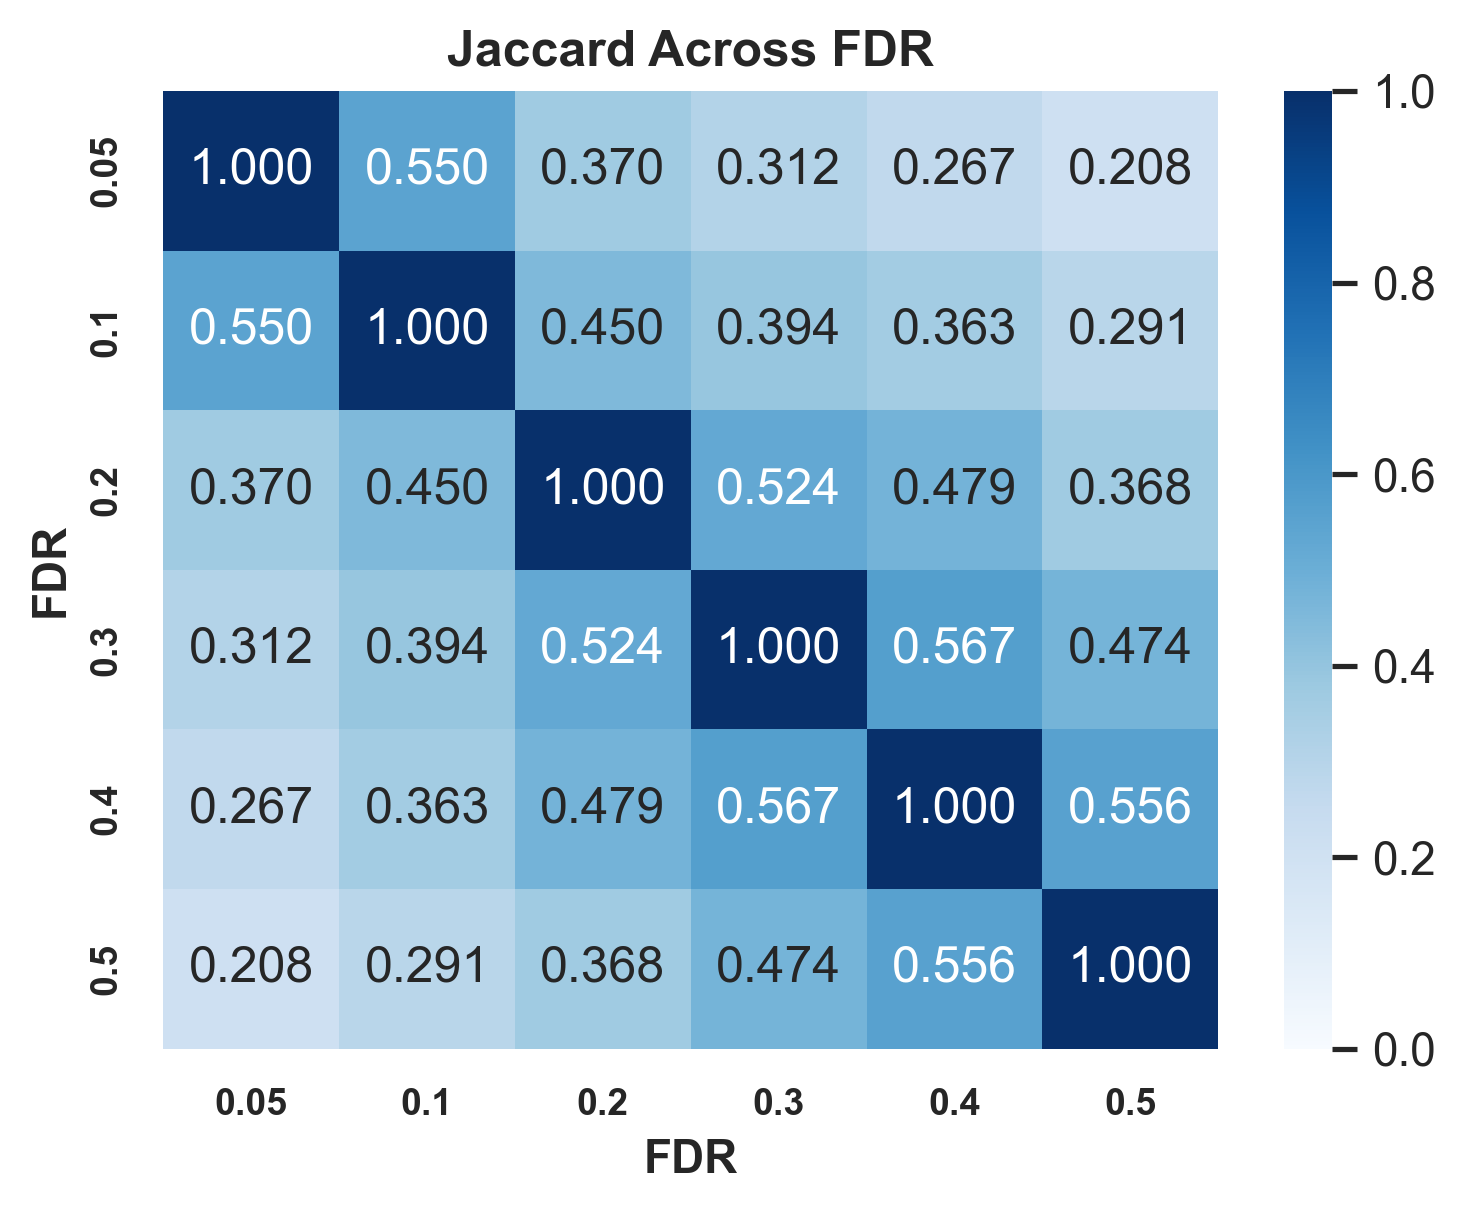

Saved Jaccard heatmap: ./Zheng_2017/figures/check_de/cd4_t_helper-naive_t_global_gene_set_jaccard_heatmap.pdf
Saved pairwise similarity table: ./Zheng_2017/output/check_de/comparison_de_fdr_gene_set_similarity_cd4_t_helper-naive_t.csv


In [15]:
# Plot only Jaccard similarity (global gene-set Jaccard) across FDR runs
def to_sym_matrix(df, value_col):
    idx = sorted(set(df['fdr_1']).union(set(df['fdr_2'])))
    mat = pd.DataFrame(np.nan, index=idx, columns=idx, dtype=float)
    for _, r in df.iterrows():
        i, j = float(r['fdr_1']), float(r['fdr_2'])
        v = float(r[value_col])
        mat.loc[i, j] = v
        mat.loc[j, i] = v
    return mat

if 'pair_df' not in globals() or pair_df is None or len(pair_df) == 0:
    fdrs = sorted(fdr_runs.keys())
    pair_rows = []
    for i, f1 in enumerate(fdrs):
        for j, f2 in enumerate(fdrs):
            if j < i:
                continue
            a = fdr_runs[f1]
            b = fdr_runs[f2]
            comp_j = component_jaccard_best_match(a['comp_sets'], b['comp_sets'])
            global_j = jaccard(a['global_set'], b['global_set'])
            ari_like, n_shared, ji_like = ri_like_first_membership(a['comp_sets'], b['comp_sets'])
            pair_rows.append({
                'fdr_1': f1,
                'fdr_2': f2,
                'component_jaccard_best_match': comp_j,
                'global_gene_set_jaccard': global_j,
                'ari_like_first_membership': ari_like,
                'ji_like_first_membership': ji_like,
                'n_shared_genes_for_ari_like': n_shared,
            })
    pair_df = pd.DataFrame(pair_rows).sort_values(['fdr_1', 'fdr_2']).reset_index(drop=True)

jaccard_col = 'global_gene_set_jaccard'
mat = to_sym_matrix(pair_df, jaccard_col)

plt.figure(figsize=(5.2, 4.2), dpi=300)
ax = sns.heatmap(mat, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1, cbar=True)
plt.title('Jaccard Across FDR', fontsize=12, fontweight='bold')
plt.xlabel('FDR', fontsize=11, fontweight='bold')
plt.ylabel('FDR', fontsize=11, fontweight='bold')
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontsize(9)
    lbl.set_fontweight('bold')
plt.tight_layout()

out_path = os.path.join(check_dir, f'{cell_type_str}_{jaccard_col}_heatmap.pdf')
plt.savefig(out_path)
plt.show()

pair_csv = os.path.join(output_dir, f'comparison_de_fdr_gene_set_similarity_{cell_type_str}.csv')
pair_df.to_csv(pair_csv, index=False)
print(f'Saved Jaccard heatmap: {out_path}')
print(f'Saved pairwise similarity table: {pair_csv}')


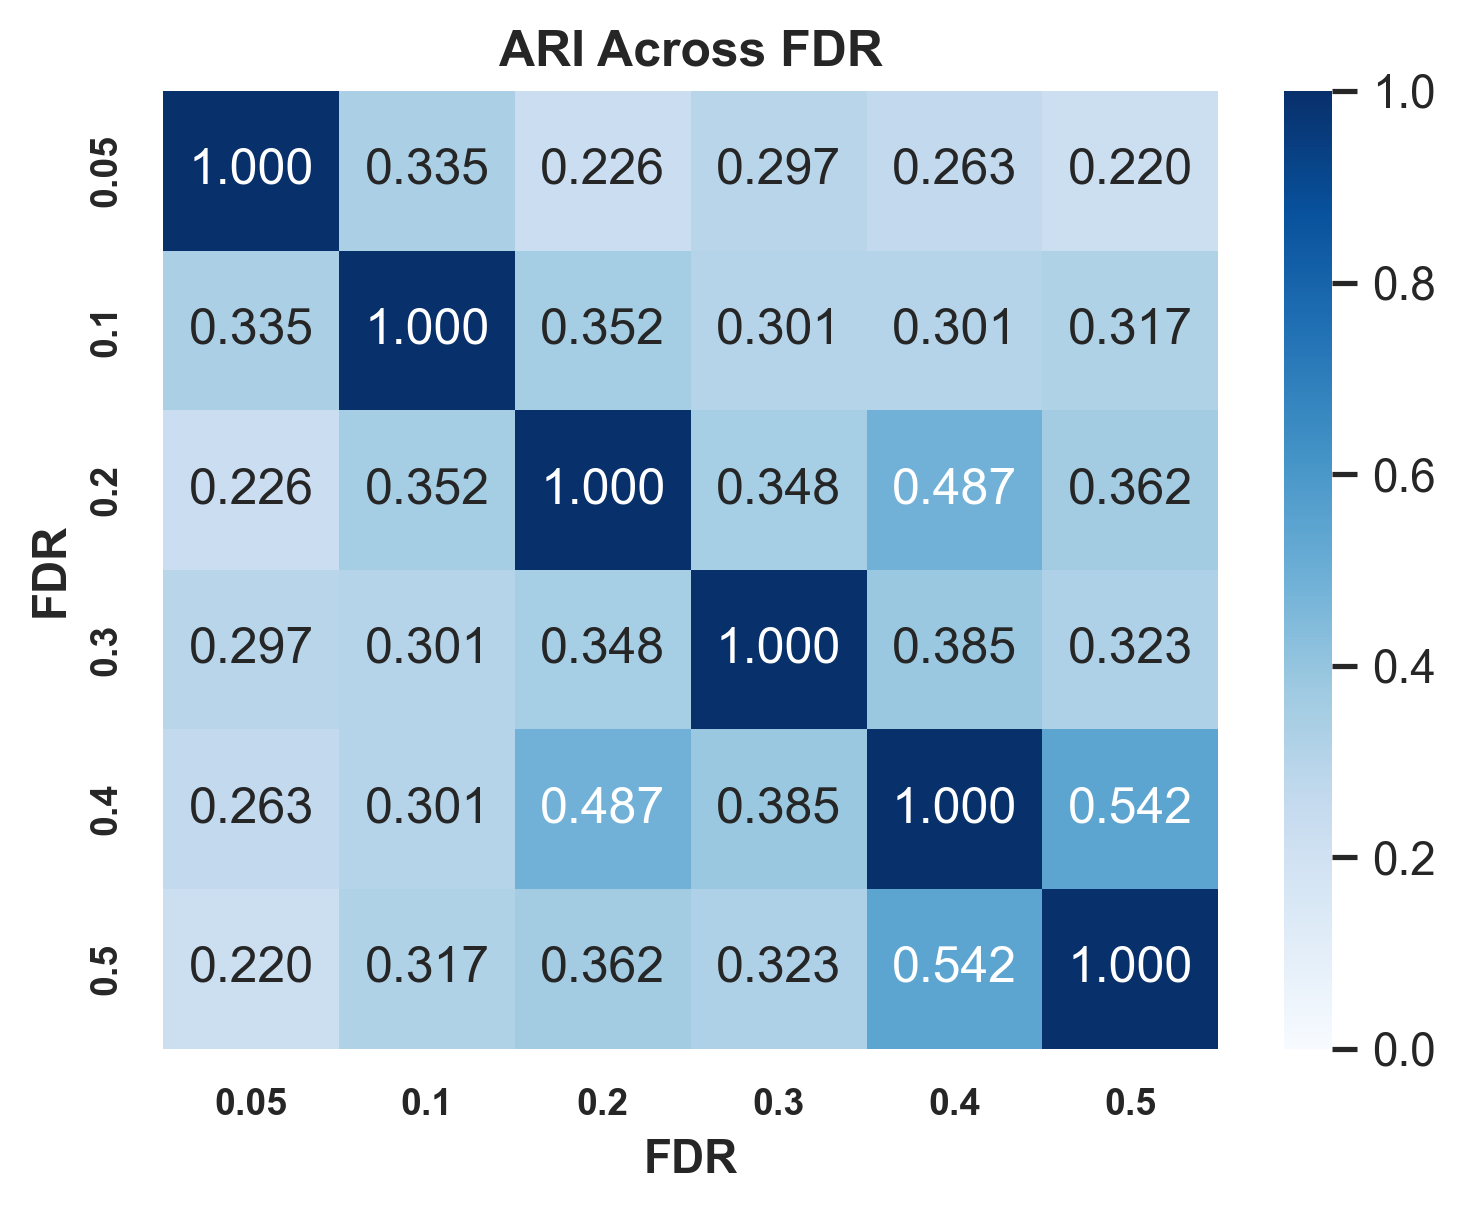

Saved ARI-like heatmap: ./Zheng_2017/figures/check_de/cd4_t_helper-naive_t_ari_like_fdr_heatmap.pdf
Saved ARI-like table: ./Zheng_2017/output/check_de/comparison_de_fdr_ari_like_cd4_t_helper-naive_t.csv


,fdr_1,fdr_2,ari_like,n_shared_genes,shared_over_union
0,0.05,0.05,1.000000,234,1.000000
1,0.05,0.10,0.334810,155,0.549645
2,0.05,0.20,0.226189,125,0.369822
3,0.05,0.30,0.296599,120,0.311688
4,0.05,0.40,0.263323,100,0.267380


In [16]:
# compute_cluster_RI-style overlap across FDR runs and visualize as a heatmap
def compute_cluster_ri_like_from_sets(comp_sets_a, comp_sets_b):
    all_a = sorted(set().union(*comp_sets_a)) if comp_sets_a else []
    all_b = sorted(set().union(*comp_sets_b)) if comp_sets_b else []
    shared = sorted(set(all_a) & set(all_b))

    if len(shared) == 0:
        return np.nan, 0, 0.0

    def first_cluster(gene, comp_sets):
        for idx, gene_set in enumerate(comp_sets):
            if gene in gene_set:
                return idx
        return -1

    labels_a = np.array([first_cluster(g, comp_sets_a) for g in shared], dtype=int)
    labels_b = np.array([first_cluster(g, comp_sets_b) for g in shared], dtype=int)
    ari = adjusted_rand_score(labels_a, labels_b)

    union_n = len(set(all_a) | set(all_b))
    ji = len(shared) / union_n if union_n > 0 else 0.0
    return float(ari), int(len(shared)), float(ji)


ri_rows = []
for f1 in fdrs:
    for f2 in fdrs:
        a = fdr_runs[f1]
        b = fdr_runs[f2]
        ari, n_shared, ji = compute_cluster_ri_like_from_sets(a['comp_sets'], b['comp_sets'])
        ri_rows.append({
            'fdr_1': f1,
            'fdr_2': f2,
            'ari_like': ari,
            'n_shared_genes': n_shared,
            'shared_over_union': ji,
        })

ri_df = pd.DataFrame(ri_rows)
ri_mat = ri_df.pivot(index='fdr_1', columns='fdr_2', values='ari_like')
ri_mat = ri_mat.loc[sorted(ri_mat.index), sorted(ri_mat.columns)]

plt.figure(figsize=(5.2, 4.2), dpi=300)
ax = sns.heatmap(ri_mat, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1, cbar=True)
plt.title('ARI Across FDR', fontsize=12, fontweight='bold')
plt.xlabel('FDR', fontsize=11, fontweight='bold')
plt.ylabel('FDR', fontsize=11, fontweight='bold')
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontsize(9)
    lbl.set_fontweight('bold')
plt.tight_layout()

ri_fig_path = os.path.join(check_dir, f'{cell_type_str}_ari_like_fdr_heatmap.pdf')
plt.savefig(ri_fig_path)
plt.show()

ri_csv_path = os.path.join(output_dir, f'comparison_de_fdr_ari_like_{cell_type_str}.csv')
ri_df.to_csv(ri_csv_path, index=False)
print(f'Saved ARI-like heatmap: {ri_fig_path}')
print(f'Saved ARI-like table: {ri_csv_path}')
ri_df.head()
